# 🚀 Lab 33: Fraud Probability Analysis with Logistic Scoring

## 📘 Lab Overview
In this lab, you will build a beginner-friendly fraud detection workflow using **logistic regression** and transaction risk scoring. You will generate a realistic synthetic transaction dataset, engineer fraud-related features, train a classification model, score transactions with fraud probabilities, classify them into business-friendly risk levels, visualize the results, and save the trained system for reuse.

### 🧒 ELI10: What is happening here?
Imagine you are a security guard at a bank. For every person walking in, you don't just say 'Thief' or 'Not a Thief.' Instead, you give them a 'suspicion score' from 0 to 100. If someone is at a 5, you let them pass. If they are at a 50, you watch them closely. If they are at a 95, you call for backup. This lab teaches a computer to do exactly that for digital money transfers!

## 🎯 Objectives
* Understand the fundamentals of fraud detection using logistic regression
* Create a transaction scoring function using multiple fraud indicators
* Implement risk classification systems for financial transactions
* Visualize fraud probability distributions and patterns
* Build a reusable fraud detection scoring system

## 🧰 Prerequisites
* Basic Python (variables, functions, lists)
* Familiarity with Pandas (tables)
* Basic understanding of financial transactions

## ⚙️ Colab Environment Setup
Before we start, we need to install our tools. We use `scikit-learn` for the math (AI), `pandas` for the data tables, and `matplotlib/seaborn` for the charts.

In [1]:
# Step 1: Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

# Step 2: Import libraries and create folders
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    roc_auc_score
)

# Ignore annoying warnings to keep the output clean
warnings.filterwarnings("ignore")

# Create project-style folders to keep our files organized
os.makedirs("data", exist_ok=True)
os.makedirs("scripts", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

print("Environment setup complete!")
print("Created folders:", os.listdir("."))

Environment setup complete!
Created folders: ['.config', 'data', 'scripts', 'visualizations', 'sample_data']


## 📥 Loading or Creating the Dataset
### 🧒 ELI10: Why generate data?
In the real world, fraud data is very private (it has people's credit card numbers!). To learn, we create 'synthetic' data that acts like real fraud but is safe to use. We make fraud look 'weird'—like large amounts of money spent at 3 AM from a brand-new account.

In [2]:
# Set random seed so everyone gets the same 'random' results
np.random.seed(42)

def generate_transaction_data(n_transactions=10000):
    """
    Generates a fake dataset of bank transactions.
    Fraudulent ones (5%) follow suspicious patterns.
    """
    data = []
    device_types = ['mobile', 'desktop', 'tablet']

    for i in range(n_transactions):
        transaction_id = f"TXN_{i+1:06d}"
        # 5% chance of being fraud
        is_fraud = 1 if np.random.random() < 0.05 else 0

        # LOGIC: Fraud is often much higher in price or very tiny 'tests'
        if is_fraud:
            amount = np.random.exponential(2000) if np.random.random() < 0.7 else np.random.uniform(1, 10)
            hour = int(np.random.choice([0, 1, 2, 3, 22, 23])) if np.random.random() < 0.6 else int(np.random.randint(0, 24))
            location_risk = int(np.random.randint(6, 11)) # High risk
            account_age = int(np.random.randint(1, 30))   # New accounts
            prev_transactions = int(np.random.randint(0, 3)) # Low history
        else:
            amount = np.random.exponential(150)
            hour = int(np.random.choice(range(8, 20))) if np.random.random() < 0.7 else int(np.random.randint(0, 24))
            location_risk = int(np.random.randint(1, 6))
            account_age = int(np.random.randint(30, 1000))
            prev_transactions = int(np.random.randint(1, 10))

        device = np.random.choice(device_types, p=[0.6, 0.3, 0.1] if is_fraud else [0.4, 0.5, 0.1])

        data.append({
            'transaction_id': transaction_id,
            'amount': round(amount, 2),
            'hour': hour,
            'device': device,
            'location_risk': location_risk,
            'account_age': account_age,
            'prev_transactions_24h': prev_transactions,
            'is_fraud': is_fraud
        })

    return pd.DataFrame(data)

# Generate and save
df = generate_transaction_data(10000)
df.to_csv("data/generated_transactions.csv", index=False)

print(f"Dataset created! Total: {len(df)}, Fraud: {df['is_fraud'].sum()}")
display(df.head())

Dataset created! Total: 10000, Fraud: 473


,transaction_id,amount,hour,device,location_risk,account_age,prev_transactions_24h,is_fraud
0,TXN_000001,451.52,20,mobile,2,496,7,0
1,TXN_000002,137.86,21,desktop,5,799,8,0
2,TXN_000003,30.10,19,mobile,2,51,9,0
3,TXN_000004,22.54,10,desktop,4,596,4,0
4,TXN_000005,373.92,3,desktop,6,28,1,1


## 🧪 Feature Engineering
### 🧒 ELI10: Teaching the computer to 'read' the data
Computers love numbers but hate text like 'mobile.' We convert 'mobile/desktop' into columns of 1s and 0s. We also create 'flags' like `is_night` because we know fraud happens more often when people are asleep!

In [3]:
# Global thresholds to define what 'suspicious' looks like
FEATURE_THRESHOLDS = {
    "high_amount_threshold": df["amount"].quantile(0.95),
    "low_amount_threshold": 10,
    "new_account_threshold": 30,
    "low_activity_threshold": 2
}

def prepare_features(df_input, thresholds=None):
    """
    Turns raw columns into mathematical features for the AI.
    """
    if thresholds is None: thresholds = FEATURE_THRESHOLDS
    df_p = df_input.copy()

    # Convert categorical 'device' to numbers (One-Hot Encoding)
    df_p['device'] = df_p['device'].astype(str).str.lower().str.strip()
    for dev in ['desktop', 'mobile', 'tablet']:
        df_p[f'device_{dev}'] = (df_p['device'] == dev).astype(int)

    # Create behavioral flags
    df_p['is_night'] = ((df_p['hour'] < 6) | (df_p['hour'] > 22)).astype(int)
    df_p['is_business_hours'] = ((df_p['hour'] >= 9) & (df_p['hour'] <= 17)).astype(int)
    df_p['log_amount'] = np.log1p(df_p['amount']) # Helps handle giant price gaps
    df_p['high_amount'] = (df_p['amount'] > thresholds["high_amount_threshold"]).astype(int)
    df_p['low_amount'] = (df_p['amount'] < thresholds["low_amount_threshold"]).astype(int)
    df_p['new_account'] = (df_p['account_age'] < thresholds["new_account_threshold"]).astype(int)
    df_p['low_activity'] = (df_p['prev_transactions_24h'] < thresholds["low_activity_threshold"]).astype(int)

    return df_p

df_features = prepare_features(df)
print("Features prepared!")
display(df_features.head())

Features prepared!


,transaction_id,amount,hour,device,location_risk,account_age,prev_transactions_24h,is_fraud,device_desktop,device_mobile,device_tablet,is_night,is_business_hours,log_amount,high_amount,low_amount,new_account,low_activity
0,TXN_000001,451.52,20,mobile,2,496,7,0,0,1,0,0,0,6.114832,0,0,0,0
1,TXN_000002,137.86,21,desktop,5,799,8,0,1,0,0,0,0,4.933466,0,0,0,0
2,TXN_000003,30.10,19,mobile,2,51,9,0,0,1,0,0,0,3.437208,0,0,0,0
3,TXN_000004,22.54,10,desktop,4,596,4,0,1,0,0,0,1,3.158701,0,0,0,0
4,TXN_000005,373.92,3,desktop,6,28,1,1,1,0,0,1,0,5.926713,0,0,1,1


## 🤖 Logistic Regression Model Training
### 🧒 ELI10: What is Logistic Regression?
It's a mathematical formula that looks at all the 'hints' (features) and calculates a probability between 0% and 100%. We use a `StandardScaler` to make sure 'Amount' (which can be 5000) doesn't drown out 'Location Risk' (which is only 1 to 10).

In [4]:
feature_columns = [
    'amount', 'log_amount', 'hour', 'location_risk', 'account_age',
    'prev_transactions_24h', 'device_desktop', 'device_mobile',
    'device_tablet', 'is_night', 'is_business_hours', 'high_amount',
    'low_amount', 'new_account', 'low_activity'
]

X = df_features[feature_columns].astype(float)
y = df_features['is_fraud']

# Split: 80% for learning, 20% for testing the model's 'final exam'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling makes all numbers the same size (between roughly -3 and 3)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print(f"Training complete! Test Accuracy: {model.score(X_test_scaled, y_test):.2%}")
print(f"ROC AUC (Ability to distinguish fraud): {roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]):.3f}")

Training complete! Test Accuracy: 100.00%
ROC AUC (Ability to distinguish fraud): 1.000


## 🎯 Transaction Scoring Function
Now we create a tool that takes a new transaction and gives us a 'Risk Level'.

In [5]:
def score_transaction(transaction_data, model, scaler, feature_columns, thresholds=None):
    if thresholds is None: thresholds = FEATURE_THRESHOLDS

    # If it's one dict, turn to DataFrame
    is_single = isinstance(transaction_data, dict)
    df_in = pd.DataFrame([transaction_data]) if is_single else transaction_data.copy()

    # Feature engineering + Scaling
    df_p = prepare_features(df_in, thresholds)
    X_sc = scaler.transform(df_p[feature_columns].astype(float))

    # Get probability of fraud
    probs = model.predict_proba(X_sc)[:, 1]

    # Classify
    categories = []
    for p in probs:
        if p < 0.3: categories.append('Safe')
        elif p < 0.7: categories.append('Suspicious')
        else: categories.append('Likely Fraud')

    return (probs[0], categories[0]) if is_single else (probs, categories)

# Test it!
sample = {'amount': 2500.0, 'hour': 2, 'device': 'mobile', 'location_risk': 8, 'account_age': 5, 'prev_transactions_24h': 1}
p, c = score_transaction(sample, model, scaler, feature_columns)
print(f"Sample Scoring -> Prob: {p:.3f}, Category: {c}")

Sample Scoring -> Prob: 1.000, Category: Likely Fraud


## 📈 Fraud Probability Visualizations
Let's see how our model performs visually.

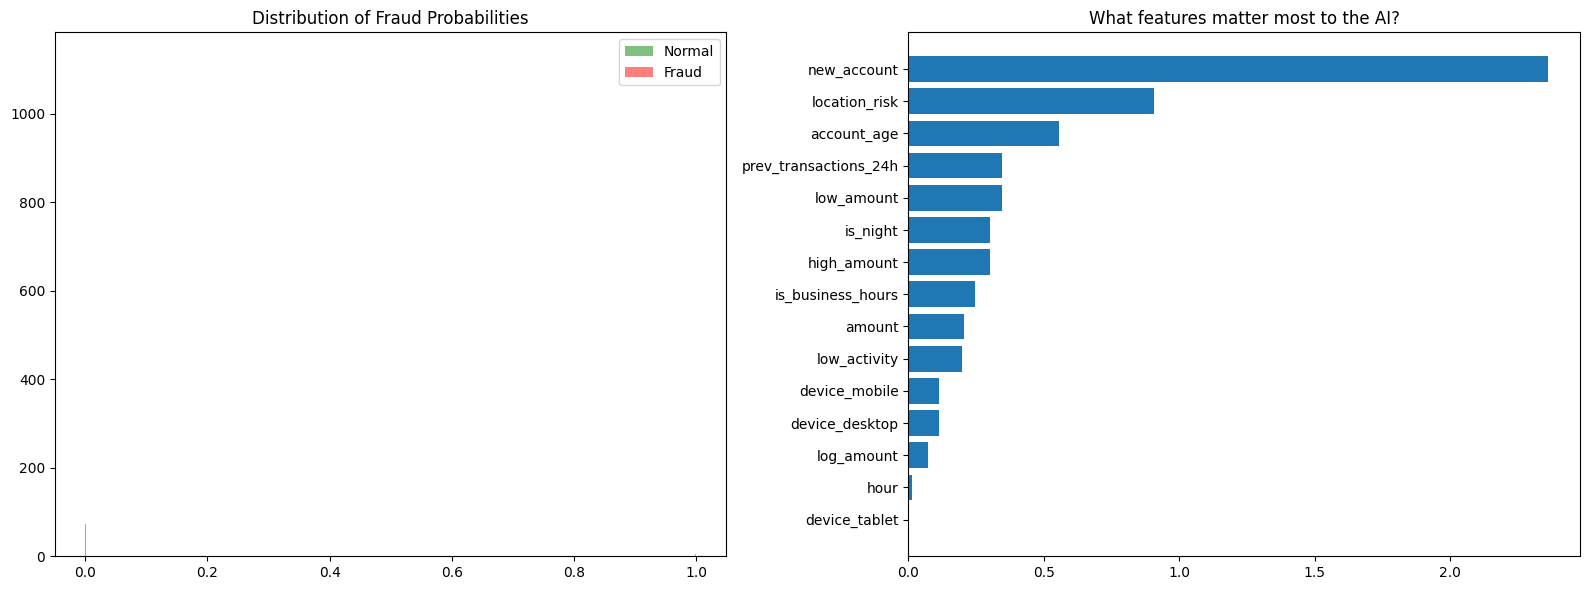

In [6]:
# Score the test set for analysis
test_raw = df.loc[X_test.index].copy()
probs, cats = score_transaction(test_raw, model, scaler, feature_columns)
test_results = test_raw.copy()
test_results['fraud_probability'] = probs
test_results['predicted_risk'] = cats

# Visualization Dashboard
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Probabilities
axes[0].hist(test_results[test_results['is_fraud']==0]['fraud_probability'], bins=50, alpha=0.5, label='Normal', color='green')
axes[0].hist(test_results[test_results['is_fraud']==1]['fraud_probability'], bins=50, alpha=0.5, label='Fraud', color='red')
axes[0].set_title('Distribution of Fraud Probabilities')
axes[0].legend()

# Plot 2: Importance
feat_imp = pd.DataFrame({'f': feature_columns, 'i': abs(model.coef_[0])}).sort_values('i')
axes[1].barh(feat_imp['f'], feat_imp['i'])
axes[1].set_title('What features matter most to the AI?')

plt.tight_layout()
plt.savefig('visualizations/fraud_analysis_dashboard.png')
plt.show()

## 🤖 Automated Fraud Detection System
This class bundles everything together into a 'production-ready' system.

In [7]:
class FraudDetectionSystem:
    def __init__(self, model, scaler, features, thresholds):
        self.model, self.scaler, self.features, self.thresholds = model, scaler, features, thresholds
        self.log = []

    def process(self, txn):
        p, cat = score_transaction(txn, self.model, self.scaler, self.features, self.thresholds)
        action = 'Approve' if cat == 'Safe' else ('Manual Review' if cat == 'Suspicious' else 'Decline')
        res = {'id': txn['transaction_id'], 'prob': float(p), 'risk': cat, 'action': action}
        self.log.append(res)
        return res

# Deployment
fs = FraudDetectionSystem(model, scaler, feature_columns, FEATURE_THRESHOLDS)
test_txn = {'transaction_id': 'TEST_99', 'amount': 4500.0, 'hour': 3, 'device': 'mobile', 'location_risk': 9, 'account_age': 1, 'prev_transactions_24h': 0}
print("Live Scoring Result:", fs.process(test_txn))

Live Scoring Result: {'id': 'TEST_99', 'prob': 0.9999830636204629, 'risk': 'Likely Fraud', 'action': 'Decline'}


## 🏁 Conclusion and Savings
We save our model and configuration so we can use it tomorrow without retraining.

In [8]:
# Save artifacts
joblib.dump(model, 'scripts/fraud_detection_model.pkl')
joblib.dump(scaler, 'scripts/fraud_scaler.pkl')
with open('scripts/feature_thresholds.json', 'w') as f: json.dump(FEATURE_THRESHOLDS, f)

# Final Checklist Verification
files = ['data/generated_transactions.csv', 'scripts/fraud_detection_model.pkl', 'visualizations/fraud_analysis_dashboard.png']
print("Verification Checklist:")
for f in files: print(f"[ {'OK' if os.path.exists(f) else '!!'} ] {f}")

Verification Checklist:
[ OK ] data/generated_transactions.csv
[ OK ] scripts/fraud_detection_model.pkl
[ OK ] visualizations/fraud_analysis_dashboard.png


# 🛠 Troubleshooting, Key Takeaways, and Real-World Applications

## 🛠 Troubleshooting Guidance

| Issue | Potential Cause | Solution |
| :--- | :--- | :--- |
| **`ValueError` during scaling** | Feature count mismatch | Ensure the `feature_columns` list matches the columns in your processed DataFrame. |
| **Low Model Accuracy** | Over-simplified features | Try adding more interaction terms or using a non-linear model like Random Forest. |
| **File Not Found** | Folder creation skipped | Rerun the first code cell to ensure `data/`, `scripts/`, and `visualizations/` exist. |
| **Device Dummy Errors** | Missing categories | Ensure `prepare_features` uses `pd.Categorical` with fixed categories: `['desktop', 'mobile', 'tablet']`. |

---

## 📚 Key Takeaways

*   **Probability vs. Binary:** Logistic Regression is powerful because it gives a **score (0 to 1)**, not just a label. This allows businesses to set their own risk appetite.
*   **Feature Engineering is King:** The raw data (time, amount) becomes much more powerful when transformed into behavioral flags like `is_night` or `log_amount`.
*   **The Scaling Necessity:** Models like Logistic Regression are sensitive to the magnitude of numbers. `StandardScaler` ensures a $5,000 amount doesn't overrule a high-risk location code.

---

## 🎓 What You Learned

1.  How to **synthesize realistic financial data** for safe machine learning practice.
2.  How to **preprocess categorical and numerical data** for an AI model.
3.  How to **evaluate a fraud model** using ROC AUC and Precision-Recall metrics.
4.  How to **build a modular scoring system** that can be deployed into a real business workflow.
5.  How to **persist models and configurations** to disk using `joblib` and `json`.

---

## 🌍 Real-World Importance

In the real world, fraud detection is a game of cat and mouse. Financial institutions use systems exactly like this to process millions of transactions per second.

*   **Banking:** Detecting credit card theft before the customer even notices.
*   **E-commerce:** Identifying "account takeover" attempts where a stranger logs in from a new device.
*   **Fintech:** Instantly deciding whether to approve a "Buy Now, Pay Later" loan.

By providing a **Risk Category**, we empower human investigators to focus on the most complex cases (Suspicious) while letting the AI handle the obvious ones (Safe/Likely Fraud).